In [1]:
import os, warnings, json, pickle
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
 
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import tensorflow as tf
import keras
from keras import layers, models, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from collections import deque

In [2]:
print("TF:", tf.__version__)
print("MediaPipe:", mp.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.18.0
MediaPipe: 0.10.33
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SEQ_LEN      = 30   
BATCH_SIZE   = 64   
EPOCHS       = 60
LR           = 1e-3
N_FEATURES   = 14   
 
DATASET_BASE = '/Users/stevennn/Downloads/DAiSEE/DataSet'
LABELS_BASE  = '/Users/stevennn/Downloads/DAiSEE/Labels'
CACHE_DIR    = './landmark_cache' 
os.makedirs(CACHE_DIR, exist_ok=True)
 
ENGAGEMENT_MAP  = {0: 0, 1: 0, 2: 1, 3: 2}
ENGAGEMENT_NAMES = ['Low', 'Moderate', 'High']
 
BOREDOM_MAP   = {0: 0, 1: 1, 2: 1, 3: 1}
BOREDOM_NAMES = ['Not Bored', 'Bored']
 
print("Config loaded.")

Config loaded.


In [5]:
import urllib.request, os
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading face landmarker model (~30MB)...")
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/'
        'face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        MODEL_PATH
    )
    print("Done.")

class LandmarkExtractor:
    LEFT_EYE   = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE  = [33,  160, 158, 133, 153, 144]
    MOUTH      = [61, 291, 39, 181, 0, 17]
    LEFT_BROW  = [336, 296, 334, 293, 300]
    RIGHT_BROW = [70,  63,  105, 66,  107]
    NOSE_TIP   = 1
    CHIN       = 152
    LEFT_EYE_C = 263
    RIGHT_EYE_C= 33
    LEFT_MOUTH = 61
    RIGHT_MOUTH= 291

    def __init__(self):
        base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
        options = mp_vision.FaceLandmarkerOptions(
            base_options=base_options,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5,
            running_mode=mp_vision.RunningMode.IMAGE
        )
        self.face_mesh   = mp_vision.FaceLandmarker.create_from_options(options)
        self._prev_ear   = None

    def reset(self):
        self._prev_ear = None

    @staticmethod
    def _ear(lm, eye_idx, w, h):
        pts = np.array([[lm[i].x * w, lm[i].y * h] for i in eye_idx])
        A = np.linalg.norm(pts[1] - pts[5])
        B = np.linalg.norm(pts[2] - pts[4])
        C = np.linalg.norm(pts[0] - pts[3])
        return (A + B) / (2.0 * C + 1e-6)

    @staticmethod
    def _mar(lm, mouth_idx, w, h):
        pts = np.array([[lm[i].x * w, lm[i].y * h] for i in mouth_idx])
        A = np.linalg.norm(pts[1] - pts[5])
        B = np.linalg.norm(pts[2] - pts[4])
        C = np.linalg.norm(pts[0] - pts[3])
        return (A + B) / (2.0 * C + 1e-6)

    @staticmethod
    def _brow_raise(lm, brow_idx, eye_idx, w, h):
        brow_y = np.mean([lm[i].y * h for i in brow_idx])
        eye_y  = np.mean([lm[i].y * h for i in eye_idx])
        return (eye_y - brow_y) / (h + 1e-6)

    @staticmethod
    def _head_pose(lm, img_shape):
        h, w = img_shape[:2]
        model_pts = np.array([
            (0.0,   0.0,    0.0),
            (0.0,  -63.6, -12.5),
            (-43.3, 32.7,  -26.0),
            (43.3,  32.7,  -26.0),
            (-28.9, -28.9, -24.1),
            (28.9,  -28.9, -24.1),
        ], dtype=np.float64)

        indices = [1, 152, 263, 33, 61, 291]
        img_pts = np.array([[lm[i].x * w, lm[i].y * h]
                             for i in indices], dtype=np.float64)

        focal  = w
        cam_mx = np.array([[focal,0,w/2],[0,focal,h/2],[0,0,1]], dtype=np.float64)
        ok, rvec, _ = cv2.solvePnP(model_pts, img_pts, cam_mx,
                                    np.zeros((4,1)), flags=cv2.SOLVEPNP_ITERATIVE)
        if not ok:
            return 0.0, 0.0, 0.0
        rmat, _ = cv2.Rodrigues(rvec)
        angles, *_ = cv2.RQDecomp3x3(rmat)
        return float(angles[0]), float(angles[1]), float(angles[2])

    def extract(self, frame_bgr):
        h, w = frame_bgr.shape[:2]
        rgb      = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result   = self.face_mesh.detect(mp_image)

        if not result.face_landmarks:
            self._prev_ear = None
            return None

        lm = result.face_landmarks[0]

        left_ear  = self._ear(lm, self.LEFT_EYE,  w, h)
        right_ear = self._ear(lm, self.RIGHT_EYE, w, h)
        avg_ear   = (left_ear + right_ear) / 2.0

        ear_vel = 0.0
        if self._prev_ear is not None:
            ear_vel = avg_ear - self._prev_ear
        self._prev_ear = avg_ear

        mar              = self._mar(lm, self.MOUTH, w, h)
        pitch, yaw, roll = self._head_pose(lm, frame_bgr.shape)

        left_brow  = self._brow_raise(lm, self.LEFT_BROW,  self.LEFT_EYE,  w, h)
        right_brow = self._brow_raise(lm, self.RIGHT_BROW, self.RIGHT_EYE, w, h)
        avg_brow   = (left_brow + right_brow) / 2.0

        nc_ratio = (lm[self.CHIN].y * h - lm[self.NOSE_TIP].y * h) / (h + 1e-6)
        ied      = abs(lm[self.LEFT_EYE_C].x - lm[self.RIGHT_EYE_C].x)

        return np.array([
            left_ear, right_ear, avg_ear, ear_vel,
            mar,
            pitch/90.0, yaw/90.0, roll/90.0,
            left_brow, right_brow, avg_brow,
            nc_ratio, ied, 1.0
        ], dtype=np.float32)


extractor = LandmarkExtractor()
dummy     = np.zeros((480, 640, 3), dtype=np.uint8)
result    = extractor.extract(dummy)
print(f"Extractor ready. Test result: {'no face (expected on blank frame)' if result is None else result.shape}")

Done.
Extractor ready. Test result: no face (expected on blank frame)


W0000 00:00:1774199716.182691 41368836 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1774199716.243607 41368836 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774199716.246169 41368840 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774199716.251133 41368842 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [6]:
from multiprocessing import Pool
import functools

os.environ['OMP_NUM_THREADS'] = '4'
cv2.setNumThreads(4)

In [7]:
def extract_features_from_video(video_path, extractor, n_frames=SEQ_LEN):
    extractor.reset()
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None
 
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames_features = []
 
    for fi in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret or frame is None:
            cap.release()
            return None
        feat = extractor.extract(frame)
        if feat is None:
            feat = np.zeros(N_FEATURES, dtype=np.float32)
        frames_features.append(feat)
 
    cap.release()
 
    if len(frames_features) != n_frames:
        return None
 
    return np.stack(frames_features)  
 
 
def build_feature_cache(df, video_dir, split_name, extractor):
    cache_path = os.path.join(CACHE_DIR, f'{split_name}_features.npz')
 
    if os.path.exists(cache_path):
        print(f"  Loading cached features for {split_name}...")
        data = np.load(cache_path, allow_pickle=True)
        return data['X'], data['y_eng'], data['y_bor'], data['clip_ids']
 
    print(f"  Extracting features for {split_name} (first time — ~20-40 min)...")
    print(f"  Features will be cached to {cache_path} for future runs.")
 

    video_index = {}
    for root, _, files in os.walk(video_dir):
        for f in files:
            if f.endswith(('.avi', '.mp4')):
                video_index[f] = os.path.join(root, f)
    print(f"  Found {len(video_index)} videos")
 
    X, y_eng, y_bor, clip_ids = [], [], [], []
    skipped = 0
 
    for i, (_, row) in enumerate(df.iterrows()):
        clip_id = row['ClipID']
        path    = video_index.get(clip_id)
 
        if path is None or not os.path.exists(path):
            skipped += 1
            continue
 
        features = extract_features_from_video(path, extractor)
 
        if features is None or np.all(features == 0):
            skipped += 1
            continue
 
        eng = ENGAGEMENT_MAP[int(row['Engagement'])]
        bor = BOREDOM_MAP[int(row['Boredom'])]
 
        X.append(features)
        y_eng.append(eng)
        y_bor.append(bor)
        clip_ids.append(clip_id)
 
        if (i + 1) % 100 == 0:
            print(f"    {i+1}/{len(df)} processed, {skipped} skipped")
 
    X        = np.array(X,       dtype=np.float32)
    y_eng    = np.array(y_eng,   dtype=np.int32)
    y_bor    = np.array(y_bor,   dtype=np.int32)
    clip_ids = np.array(clip_ids)
 
    np.savez_compressed(cache_path,
                        X=X, y_eng=y_eng, y_bor=y_bor, clip_ids=clip_ids)
    print(f"  Saved {len(X)} samples to cache. Skipped: {skipped}")
    return X, y_eng, y_bor, clip_ids

In [8]:
train_df = pd.read_csv(f'{LABELS_BASE}/TrainLabels.csv')
val_df   = pd.read_csv(f'{LABELS_BASE}/ValidationLabels.csv')
test_df  = pd.read_csv(f'{LABELS_BASE}/TestLabels.csv')
 
for df in [train_df, val_df, test_df]:
    df.columns = df.columns.str.strip()
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
extractor = LandmarkExtractor()
 
print("\n=== Extracting train features ===")
X_train, y_eng_train, y_bor_train, _ = build_feature_cache(
    train_df, f'{DATASET_BASE}/Train', 'train', extractor)
 
print("\n=== Extracting val features ===")
X_val, y_eng_val, y_bor_val, _ = build_feature_cache(
    val_df, f'{DATASET_BASE}/Validation', 'val', extractor)
 
print("\n=== Extracting test features ===")
X_test, y_eng_test, y_bor_test, _ = build_feature_cache(
    test_df, f'{DATASET_BASE}/Test', 'test', extractor)
 
print(f"\nTrain: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Feature shape per sample: {X_train.shape[1:]}  (seq_len, n_features)")
 
print("\nEngagement distribution (train):")
for cls, name in enumerate(ENGAGEMENT_NAMES):
    n = (y_eng_train == cls).sum()
    print(f"  {cls} {name}: {n} ({n/len(y_eng_train)*100:.1f}%)")
 
print("\nBoredom distribution (train):")
for cls, name in enumerate(BOREDOM_NAMES):
    n = (y_bor_train == cls).sum()
    print(f"  {cls} {name}: {n} ({n/len(y_bor_train)*100:.1f}%)")

Train: 5358 | Val: 1429 | Test: 1784

=== Extracting train features ===
  Extracting features for train (first time — ~20-40 min)...
  Features will be cached to ./landmark_cache/train_features.npz for future runs.


W0000 00:00:1774199907.142482 41371227 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1774199907.146227 41371227 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1774199907.147309 41371229 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774199907.154095 41371232 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  Found 5482 videos
    100/5358 processed, 0 skipped
    200/5358 processed, 0 skipped
    300/5358 processed, 0 skipped
    400/5358 processed, 0 skipped
    500/5358 processed, 0 skipped
    600/5358 processed, 0 skipped
    700/5358 processed, 0 skipped
    800/5358 processed, 0 skipped
    900/5358 processed, 0 skipped
    1000/5358 processed, 0 skipped
    1100/5358 processed, 0 skipped
    1200/5358 processed, 0 skipped
    1300/5358 processed, 0 skipped
    1400/5358 processed, 0 skipped
    1500/5358 processed, 0 skipped
    1600/5358 processed, 0 skipped
    1700/5358 processed, 0 skipped
    1800/5358 processed, 0 skipped
    1900/5358 processed, 0 skipped
    2000/5358 processed, 0 skipped


[mpeg4 @ 0x12c722ee0] I cbpy damaged at 16 8
[mpeg4 @ 0x12c722ee0] Error at MB: 344
[mpeg4 @ 0x12c722ee0] I cbpy damaged at 16 8
[mpeg4 @ 0x12c722ee0] Error at MB: 344
[mpeg4 @ 0x12c722ee0] I cbpy damaged at 16 8
[mpeg4 @ 0x12c722ee0] Error at MB: 344


    2100/5358 processed, 0 skipped
    2200/5358 processed, 0 skipped
    2300/5358 processed, 0 skipped
    2400/5358 processed, 0 skipped
    2500/5358 processed, 0 skipped
    2600/5358 processed, 0 skipped
    2700/5358 processed, 0 skipped
    2800/5358 processed, 0 skipped
    2900/5358 processed, 0 skipped
    3000/5358 processed, 0 skipped
    3100/5358 processed, 0 skipped
    3200/5358 processed, 0 skipped
    3300/5358 processed, 0 skipped
    3400/5358 processed, 0 skipped
    3500/5358 processed, 0 skipped
    3600/5358 processed, 0 skipped
    3700/5358 processed, 0 skipped
    3800/5358 processed, 0 skipped
    3900/5358 processed, 0 skipped
    4000/5358 processed, 0 skipped
    4100/5358 processed, 0 skipped
    4200/5358 processed, 0 skipped
    4300/5358 processed, 0 skipped
    4400/5358 processed, 0 skipped
    4500/5358 processed, 0 skipped
    4600/5358 processed, 0 skipped
    4700/5358 processed, 0 skipped
    4800/5358 processed, 0 skipped
    4900/5358 proces

In [9]:
scaler = StandardScaler()
N_tr, T, F = X_train.shape
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N_tr, T, F)
 
N_v = X_val.shape[0]
X_val_scaled   = scaler.transform(X_val.reshape(-1, F)).reshape(N_v, T, F)
 
N_te = X_test.shape[0]
X_test_scaled  = scaler.transform(X_test.reshape(-1, F)).reshape(N_te, T, F)
 
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to feature_scaler.pkl")
print(f"Feature means: {scaler.mean_[:5].round(3)}")

Scaler saved to feature_scaler.pkl
Feature means: [0.282 0.282 0.282 0.    1.528]


In [10]:
def get_weights(y):
    classes = np.unique(y)
    w = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes.tolist(), w.tolist()))
 
eng_weights = get_weights(y_eng_train)
bor_weights = get_weights(y_bor_train)
 
print("Engagement class weights:", {k: round(v,3) for k,v in eng_weights.items()})
print("Boredom class weights:",    {k: round(v,3) for k,v in bor_weights.items()})

Engagement class weights: {0: 7.231, 1: 0.682, 2: 0.716}
Boredom class weights: {0: 1.101, 1: 0.916}


In [11]:
def build_model(seq_len=SEQ_LEN, n_features=N_FEATURES):

    inputs = layers.Input(shape=(seq_len, n_features), name='landmarks')
 
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3,
                    recurrent_dropout=0.1),
        name='bi_lstm_1'
    )(inputs)
 
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=True, dropout=0.3),
        name='bi_lstm_2'
    )(x)
 
    attn   = layers.Dense(1, activation='tanh', name='attn_score')(x)
    attn   = layers.Softmax(axis=1, name='attn_weights')(attn)
    x      = layers.Multiply(name='attn_apply')([x, attn])
    x      = layers.Lambda(lambda z: tf.reduce_sum(z, axis=1),
                           name='attn_pool')(x)
 
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
 
    eng = layers.Dense(32, activation='relu', name='eng_h')(x)
    eng = layers.Dropout(0.2)(eng)
    eng_out = layers.Dense(3, activation='softmax', name='engagement')(eng)
 
    bor = layers.Dense(32, activation='relu', name='bor_h')(x)
    bor = layers.Dropout(0.2)(bor)
    bor_out = layers.Dense(2, activation='softmax', name='boredom')(bor)
 
    model = models.Model(inputs=inputs,
                         outputs={'engagement': eng_out, 'boredom': bor_out},
                         name='EngageTrack_v4')
    return model
 
 
model = build_model()
model.summary()
print(f"\nTotal params: {model.count_params():,}")

I0000 00:00:1774201671.735417 41367295 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774201671.735781 41367295 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "EngageTrack_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmarks           │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_1           │ (None, 30, 128)   │     40,448 │ landmarks[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_2           │ (None, 30, 64)    │     41,216 │ bi_lstm_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 30, 1)     │         65 │ bi_lstm_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, 30, 1)     │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_apply          │ (None, 30, 64)    │          0 │ bi_lstm_2[0][0],  │
│ (Multiply)          │                   │            │ attn_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_pool (Lambda)  │ (None, 64)        │          0 │ attn_apply[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ attn_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bor_h (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eng_h (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ bor_h[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ eng_h[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boredom (Dense)     │ (None, 2)         │         66 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement (Dense)  │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 90,470 (353.40 KB)

 Trainable params: 90,342 (352.90 KB)

 Non-trainable params: 128 (512.00 B)


Total params: 90,470


In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss={
        'engagement': keras.losses.SparseCategoricalCrossentropy(),
        'boredom':    keras.losses.SparseCategoricalCrossentropy(),
    },
    loss_weights={'engagement': 1.0, 'boredom': 0.8},
    metrics={
        'engagement': ['accuracy'],
        'boredom':    ['accuracy'],
    }
)
print("Model compiled.")

Model compiled.


In [13]:
def build_sample_weights(y_eng, y_bor, eng_w, bor_w):
    n = len(y_eng)
    w = np.ones(n, dtype=np.float32)
    for i in range(n):
        we = eng_w.get(int(y_eng[i]), 1.0)
        wb = bor_w.get(int(y_bor[i]), 1.0)
        w[i] = (we + wb) / 2.0
    w = w / (w.mean() + 1e-8)
    return w
 
sw_train = build_sample_weights(y_eng_train, y_bor_train, eng_weights, bor_weights)
print(f"Sample weight range: {sw_train.min():.2f} – {sw_train.max():.2f}")
 
 

Sample weight range: 0.80 – 4.17


In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'engagetrack_v4_best.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

In [15]:
print("=" * 60)
print("Training EngageTrack v4 — Landmark LSTM")
print(f"  Train: {len(X_train_scaled)} samples")
print(f"  Val:   {len(X_val_scaled)} samples")
print("=" * 60)
 
history = model.fit(
    X_train_scaled,
    {'engagement': y_eng_train, 'boredom': y_bor_train},
    sample_weight=sw_train,
    validation_data=(
        X_val_scaled,
        {'engagement': y_eng_val, 'boredom': y_bor_val}
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
 

Training EngageTrack v4 — Landmark LSTM
  Train: 5358 samples
  Val:   1429 samples
Epoch 1/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - boredom_accuracy: 0.5205 - boredom_loss: 1.0446 - engagement_accuracy: 0.3483 - engagement_loss: 2.0173 - loss: 2.8595
Epoch 1: val_loss improved from None to 1.51642, saving model to engagetrack_v4_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - boredom_accuracy: 0.5261 - boredom_loss: 0.9640 - engagement_accuracy: 0.3707 - engagement_loss: 1.7668 - loss: 2.5460 - val_boredom_accuracy: 0.6928 - val_boredom_loss: 0.6321 - val_engagement_accuracy: 0.4962 - val_engagement_loss: 1.0047 - val_loss: 1.5164 - learning_rate: 0.0010
Epoch 2/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - boredom_accuracy: 0.5280 - boredom_loss: 0.8120 - engagement_accuracy: 0.4040 - engagement_loss: 1.3814 - loss: 2.0375
Epoch 2: val_loss improved from 1.51642 to 1.48851, saving model to engagetrack_v4_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - boredom_accuracy: 0.537

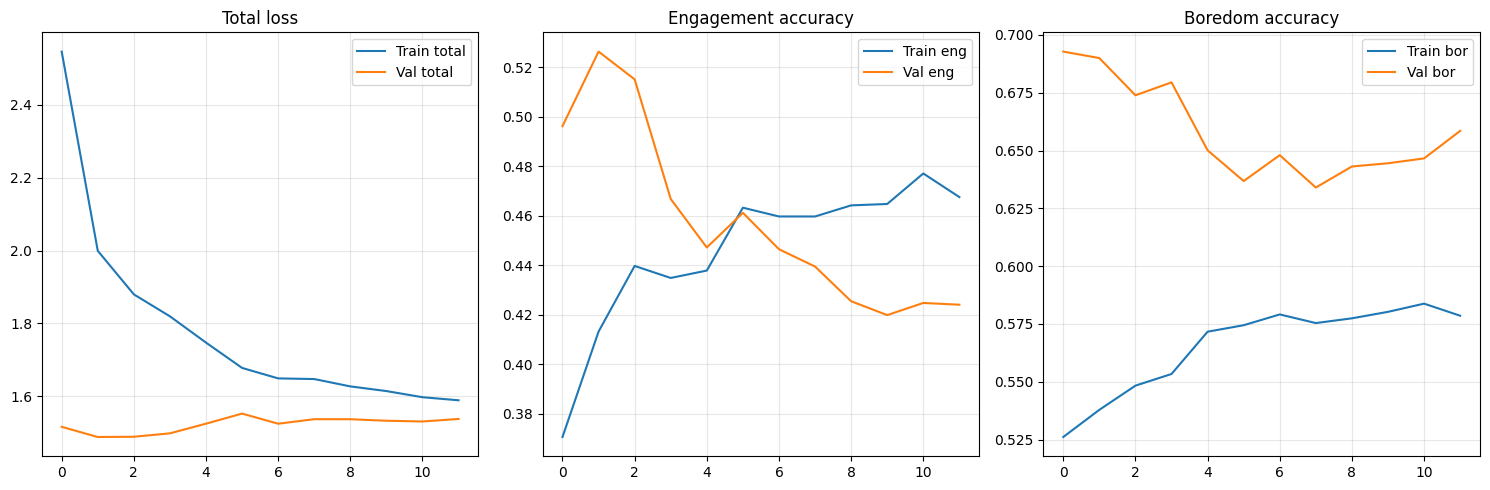

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
axes[0].plot(history.history['loss'],                   label='Train total')
axes[0].plot(history.history['val_loss'],               label='Val total')
axes[0].set_title('Total loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
axes[1].plot(history.history['engagement_accuracy'],    label='Train eng')
axes[1].plot(history.history['val_engagement_accuracy'],label='Val eng')
axes[1].set_title('Engagement accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
 
axes[2].plot(history.history['boredom_accuracy'],       label='Train bor')
axes[2].plot(history.history['val_boredom_accuracy'],   label='Val bor')
axes[2].set_title('Boredom accuracy'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_curves_v4.png', dpi=150)
plt.show()


Engagement:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       166
    Moderate       0.58      0.77      0.66       813
        High       0.37      0.28      0.32       450

    accuracy                           0.53      1429
   macro avg       0.32      0.35      0.33      1429
weighted avg       0.44      0.53      0.47      1429


Boredom:
              precision    recall  f1-score   support

   Not Bored       0.51      0.18      0.27       446
       Bored       0.71      0.92      0.80       983

    accuracy                           0.69      1429
   macro avg       0.61      0.55      0.54      1429
weighted avg       0.65      0.69      0.64      1429



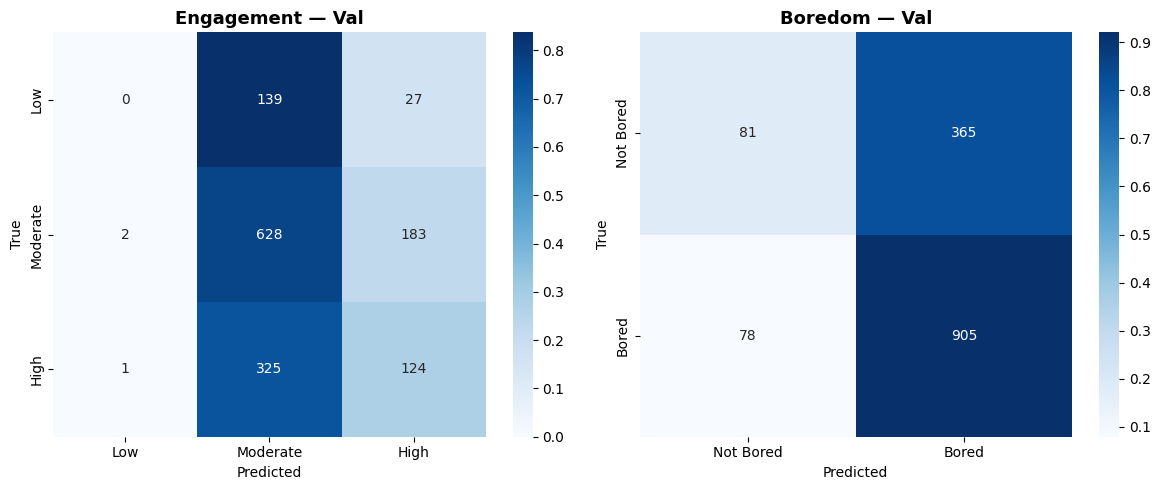


Engagement:
              precision    recall  f1-score   support

         Low       0.07      0.03      0.04        88
    Moderate       0.52      0.72      0.60       882
        High       0.52      0.33      0.40       814

    accuracy                           0.51      1784
   macro avg       0.37      0.36      0.35      1784
weighted avg       0.50      0.51      0.48      1784


Boredom:
              precision    recall  f1-score   support

   Not Bored       0.51      0.09      0.16       823
       Bored       0.54      0.92      0.68       961

    accuracy                           0.54      1784
   macro avg       0.53      0.51      0.42      1784
weighted avg       0.53      0.54      0.44      1784



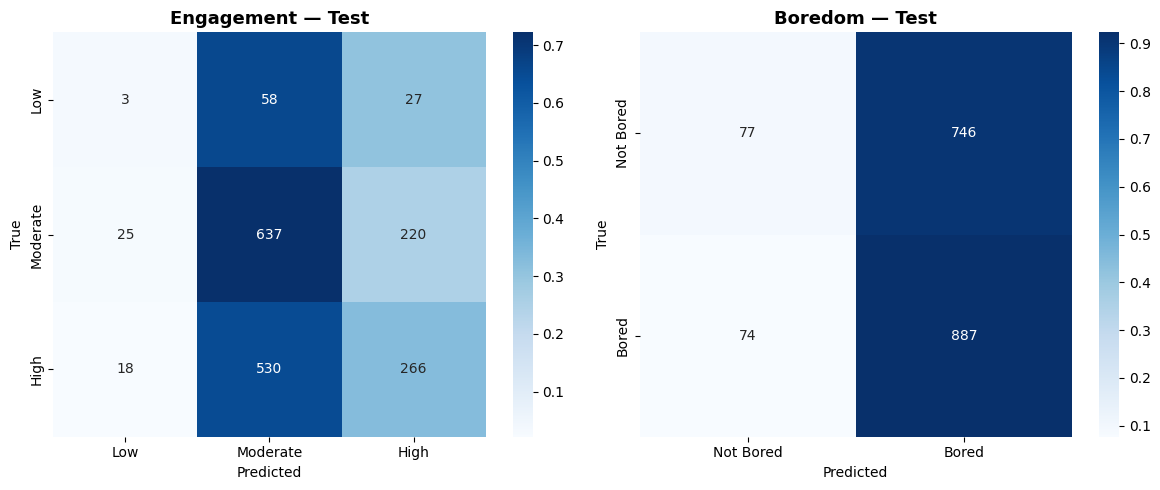

In [17]:
def evaluate(model, X, y_eng, y_bor, split='Val'):
    preds   = model.predict(X, verbose=0)
    eng_pred = np.argmax(preds['engagement'], axis=1)
    bor_pred = np.argmax(preds['boredom'],    axis=1)
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
    for ax, y_true, y_pred, names, title in [
        (axes[0], y_eng, eng_pred, ENGAGEMENT_NAMES, 'Engagement'),
        (axes[1], y_bor, bor_pred, BOREDOM_NAMES,    'Boredom'),
    ]:
        cm      = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=names, yticklabels=names)
        ax.set_title(f'{title} — {split}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
 
        print(f"\n{'='*50}")
        print(f"{title}:")
        print(classification_report(y_true, y_pred,
                                     target_names=names, zero_division=0))
 
    plt.tight_layout()
    plt.savefig(f'eval_v4_{split.lower()}.png', dpi=150)
    plt.show()
 
 
evaluate(model, X_val_scaled,  y_eng_val,  y_bor_val,  split='Val')
evaluate(model, X_test_scaled, y_eng_test, y_bor_test, split='Test')

In [19]:
def compute_attention_score(eng_probs, bor_probs):


    eng_score = eng_probs[0] * 0.0 + eng_probs[1] * 0.5 + eng_probs[2] * 1.0
 
    bor_penalty = bor_probs[1] * 0.3
 
    raw = eng_score - bor_penalty
    raw = np.clip(raw, 0, 1)
    return float(raw * 100)

In [20]:
dummy_eng = np.array([0.1, 0.2, 0.7])   # highly engaged
dummy_bor = np.array([0.9, 0.1])          # not bored
score = compute_attention_score(dummy_eng, dummy_bor)
print(f"Sample attention score (highly engaged, not bored): {score:.1f}/100")
 
dummy_eng2 = np.array([0.6, 0.3, 0.1])  # low engagement
dummy_bor2 = np.array([0.3, 0.7])         # bored
score2 = compute_attention_score(dummy_eng2, dummy_bor2)
print(f"Sample attention score (disengaged, bored): {score2:.1f}/100")

Sample attention score (highly engaged, not bored): 77.0/100
Sample attention score (disengaged, bored): 4.0/100


In [21]:
class AttentionPredictor:


    def __init__(self, model, scaler, seq_len=SEQ_LEN):
        self.model     = model
        self.scaler    = scaler
        self.seq_len   = seq_len
        self.extractor = LandmarkExtractor()
        self._buffer   = deque(maxlen=seq_len)
        self._ema      = None
        self._alpha    = 0.3   
 
    @classmethod
    def load(cls, model_path, scaler_path):
        m = keras.models.load_model(model_path)
        with open(scaler_path, 'rb') as f:
            s = pickle.load(f)
        return cls(m, s)
 
    def reset(self):
        self.extractor.reset()
        self._buffer = deque(maxlen=self.seq_len)
        self._ema    = None
 
    def update(self, frame_bgr):

        feat = self.extractor.extract(frame_bgr)
        if feat is None:
            feat = np.zeros(N_FEATURES, dtype=np.float32)
        self._buffer.append(feat)
 
        if len(self._buffer) < self.seq_len:
            return None   # still buffering
 
        # Build scaled sequence
        seq    = np.stack(self._buffer)                    # (T, F)
        scaled = self.scaler.transform(seq)               # (T, F)
        inp    = scaled[np.newaxis].astype(np.float32)    # (1, T, F)
 
        preds  = self.model.predict(inp, verbose=0)
        eng_p  = preds['engagement'][0]   # (3,)
        bor_p  = preds['boredom'][0]      # (2,)
 
        # EMA smoothing on probabilities
        if self._ema is None:
            self._ema = {'eng': eng_p.copy(), 'bor': bor_p.copy()}
        else:
            self._ema['eng'] = self._alpha * eng_p + (1-self._alpha) * self._ema['eng']
            self._ema['bor'] = self._alpha * bor_p + (1-self._alpha) * self._ema['bor']
 
        eng_p_smooth = self._ema['eng']
        bor_p_smooth = self._ema['bor']
 
        eng_cls = int(np.argmax(eng_p_smooth))
        bor_cls = int(np.argmax(bor_p_smooth))
 
        attn_score = compute_attention_score(eng_p_smooth, bor_p_smooth)
 
        alert = None
        if attn_score < 30:
            alert = 'Low attention detected'
        elif bor_cls == 1 and bor_p_smooth[1] > 0.7:
            alert = 'Student appears bored'
        elif eng_cls == 0 and eng_p_smooth[0] > 0.6:
            alert = 'Student appears disengaged'
 
        return {
            'attention_score': round(attn_score, 1),
            'engagement': {
                'class': eng_cls,
                'label': ENGAGEMENT_NAMES[eng_cls],
                'confidence': round(float(eng_p_smooth[eng_cls]), 3),
                'probs': [round(float(p), 3) for p in eng_p_smooth],
            },
            'boredom': {
                'class': bor_cls,
                'label': BOREDOM_NAMES[bor_cls],
                'confidence': round(float(bor_p_smooth[bor_cls]), 3),
                'probs': [round(float(p), 3) for p in bor_p_smooth],
            },
            'alert': alert,
            'color': (
                '#22c55e' if attn_score >= 65 else
                '#eab308' if attn_score >= 40 else
                '#ef4444'
            )
        }
 
 
print("AttentionPredictor class ready.")

AttentionPredictor class ready.


In [22]:
model.save('engagetrack_v4_final.keras')
print("Model saved: engagetrack_v4_final.keras")

Model saved: engagetrack_v4_final.keras


In [24]:
import PIL.Image, io
from IPython.display import display, clear_output
 
def run_webcam_notebook(model, scaler, camera_index=0, max_frames=500):
    
    predictor = AttentionPredictor(model, scaler)
    cap       = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Could not open camera"); return
 
    frame_count = 0
    last_result = None
 
    try:
        while frame_count < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
 
            # Run inference every 5 frames
            if frame_count % 5 == 0:
                result = predictor.update(frame)
                if result:
                    last_result = result
 
            # Draw overlay
            out = frame.copy()
            if last_result:
                score = last_result['attention_score']
                label = last_result['engagement']['label']
                color_hex = last_result['color']
                # Convert hex to BGR
                r = int(color_hex[1:3], 16)
                g = int(color_hex[3:5], 16)
                b = int(color_hex[5:7], 16)
                color_bgr = (b, g, r)
 
                # Score bar at top
                bar_w = int(frame.shape[1] * score / 100)
                cv2.rectangle(out, (0, 0), (frame.shape[1], 8), (50,50,50), -1)
                cv2.rectangle(out, (0, 0), (bar_w, 8), color_bgr, -1)
 
                # Text overlay
                cv2.rectangle(out, (10, 14), (300, 60), (0,0,0), -1)
                cv2.putText(out, f"Attention: {score:.0f}/100",
                            (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_bgr, 2)
                cv2.putText(out, f"Engagement: {label}",
                            (15, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)
 
                if last_result.get('alert'):
                    cv2.putText(out, f"! {last_result['alert']}",
                                (15, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,80,255), 2)
            else:
                cv2.putText(out, f"Buffering... {len(predictor._buffer)}/{SEQ_LEN}",
                            (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (150,150,150), 1)
 
            # Display inline
            rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
            img = PIL.Image.fromarray(rgb)
            buf = io.BytesIO()
            img.save(buf, format='JPEG', quality=75)
            buf.seek(0)
            clear_output(wait=True)
            display(PIL.Image.open(buf))
            frame_count += 1
 
    except KeyboardInterrupt:
        print("Stopped.")
    finally:
        cap.release()
        print(f"Closed after {frame_count} frames.")
 